In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#data loading and understanding..

In [2]:
df = pd.read_csv("../data/ibm.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.columns:
    print(f'{col} :{df[col].nunique()}')
    # unique values 

customerID :7043
gender :2
SeniorCitizen :2
Partner :2
Dependents :2
tenure :73
PhoneService :2
MultipleLines :3
InternetService :3
OnlineSecurity :3
OnlineBackup :3
DeviceProtection :3
TechSupport :3
StreamingTV :3
StreamingMovies :3
Contract :3
PaperlessBilling :2
PaymentMethod :4
MonthlyCharges :1585
TotalCharges :6531
Churn :2


# data cleaning and preprocessing

In [11]:
df_clean = df.copy()

In [12]:
df_clean["customerID"].head()

0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: str

In [13]:
df_clean.drop("customerID",axis=1,inplace=True)
#removing customerID as it unnessary , not any meaning full impact to decide churn.

In [14]:
df_clean.columns
#checking whtether customerid is removed or not.

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [15]:
df_clean.dtypes
# here total charge is represent str ??? because some rows contain blank spaces (" ").preventing pandas recognizing the column as numeric

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [16]:
(df_clean["TotalCharges"]==" ").sum()

np.int64(11)

In [17]:
#conveting total charge to numeric value
df_clean["TotalCharges"]=pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)
# coerce is an option in pandas functions like pd.to_numeric() and pd.to_datetime(). it says if value can't be converted ,don't raise an erro -replace with with NaN or NaT

In [18]:
(df_clean['TotalCharges']=='').sum()

np.int64(0)

In [19]:
df_clean[df_clean['TotalCharges'].isnull()]
#investing the missing rows .

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [20]:
df_clean.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [21]:
df_clean.dropna(inplace=True) 
#dropping that 11 missing values

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df_clean.shape
#checking new shape

(7032, 20)

In [24]:
df_clean.info()
#verfying dataset to ensure total charge is appered as float or not 

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

# Exploratory Data analysis..

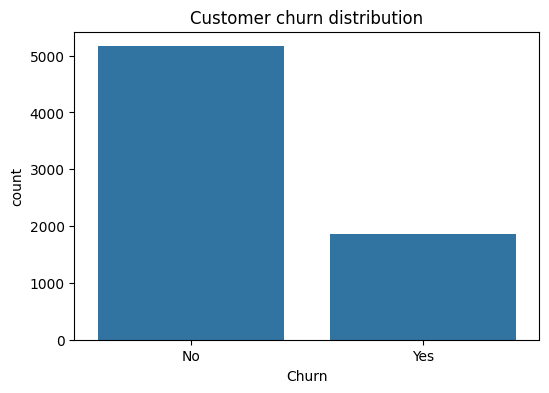

In [25]:
#Q.how many customers leave the company ?
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean ,x="Churn")
plt.title("Customer churn distribution")
plt.show()

this explains most customer stay with the company ,while smaller portion is churn. this indicates that the dataset is slighlty imbalanced ,which should be considered during model evaluation.

In [26]:
df_clean["Churn"].value_counts(normalize=True)*100
# with normalize it gives proportion of No and yes value.

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

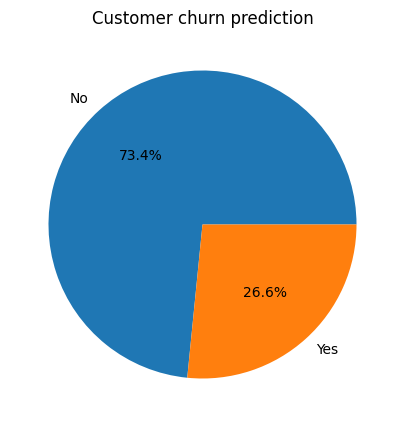

In [27]:
df_clean['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5)
)
plt.title("Customer churn prediction")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

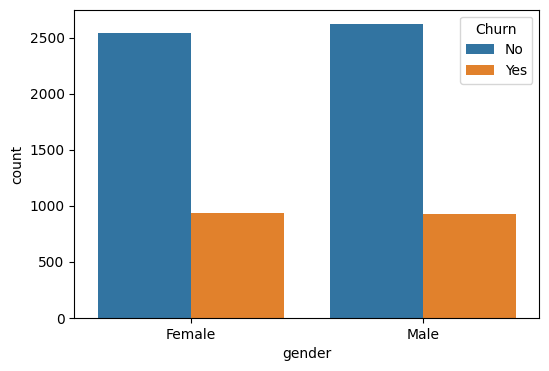

In [28]:
# Gender vs churn
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x="gender",
    hue="Churn"

)
plt.show
#In Seaborn, hue adds another categorical variable by using different colors.

this shows that the male and female customer shows very similar churn behaviour . Gender alone is unlikely to be an impotant predictor ..

<Axes: xlabel='SeniorCitizen', ylabel='count'>

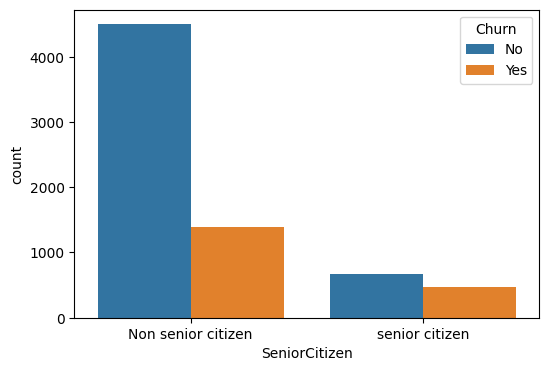

In [29]:
#Senior citizen vs churn
df_clean['SeniorCitizen']=df_clean['SeniorCitizen'].map({
    0:"Non senior citizen",
    1:"senior citizen"
})
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x='SeniorCitizen',
    hue="Churn"
)


senior citizens appear to churn at a higher rate than non-senior customers

<Axes: xlabel='Contract', ylabel='count'>

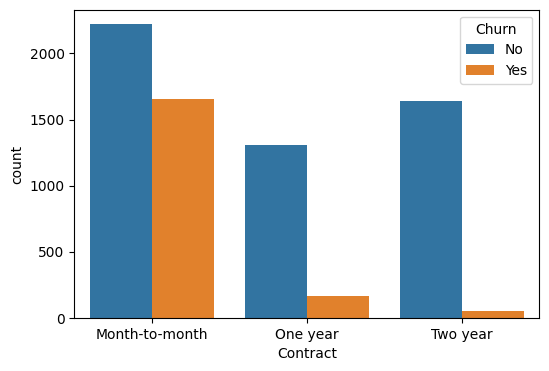

In [30]:
#Contract type vs churn
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn"
)

this shows that customers with month-month contracts are much likely to leave,while long-term contracts significantly improve customer relations.

<Axes: xlabel='InternetService', ylabel='count'>

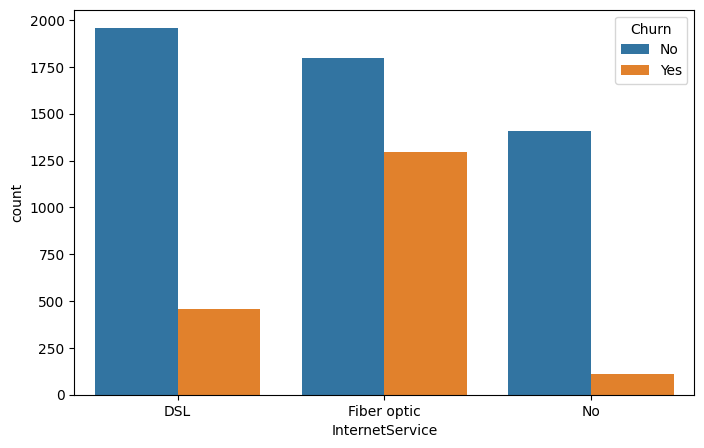

In [31]:
#InternetService vs churn
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_clean,
    x="InternetService",
    hue="Churn"
)

it is observed that fibre optic internet service has highest churn

Text(0.5, 1.0, 'Payment Method vs Churn')

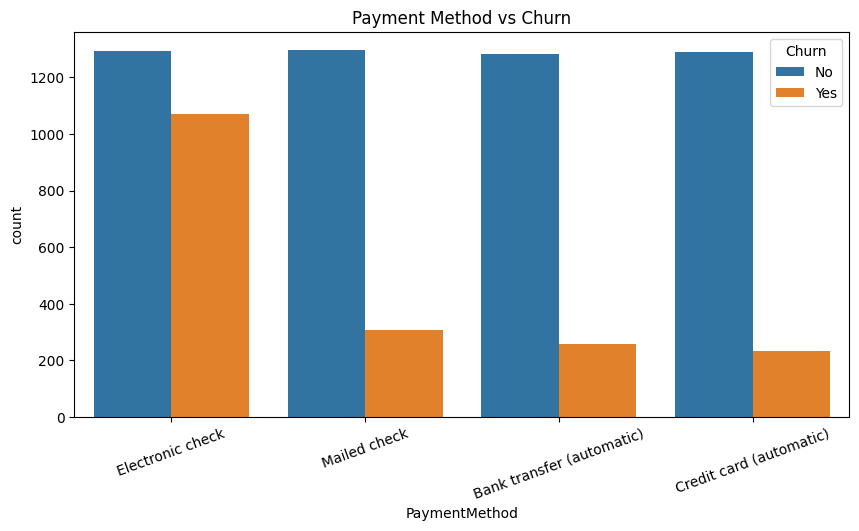

In [32]:
#Payment Method vs Churn
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_clean,
    x="PaymentMethod",
    hue="Churn"
)
plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")

Usually ,Electronic check customers churn more.

<function matplotlib.pyplot.show(close=None, block=None)>

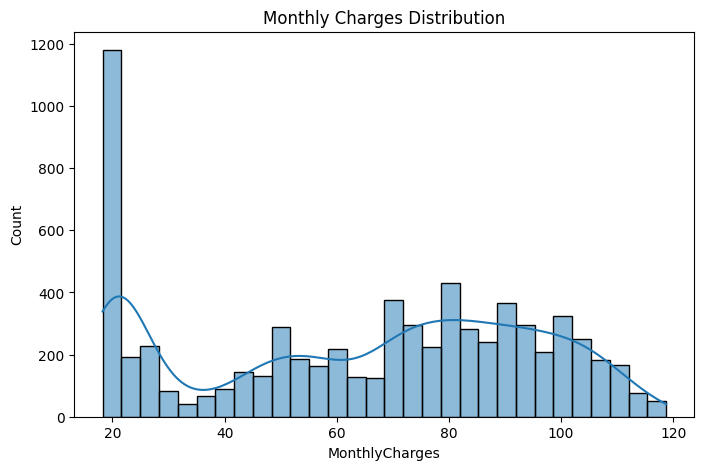

In [33]:
#Monthtly charge Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df_clean["MonthlyCharges"],
    bins=30,
    kde=True

)
plt.title("Monthly Charges Distribution")
plt.show

Text(0.5, 1.0, 'Monthly Charges vs Churn')

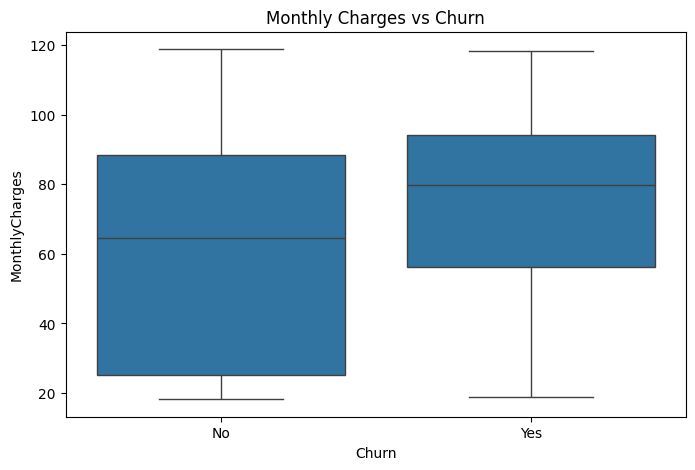

In [34]:
#Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)
plt.title("Monthly Charges vs Churn")

Churn = Yes has a higher median Monthly Charge.
Churn = No has a lower median Monthly Charge.

<function matplotlib.pyplot.show(close=None, block=None)>

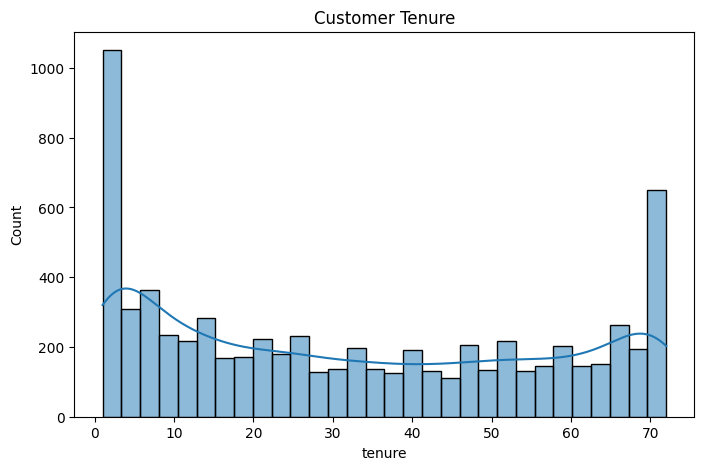

In [35]:
# Tenure Distribution => this shows how long customer stayed with company stayed with company..
plt.figure(figsize=(8,5))
sns.histplot(
    df_clean['tenure'],
    bins=30,
    kde=True
)
plt.title("Customer Tenure")
plt.show

<Axes: xlabel='Churn', ylabel='tenure'>

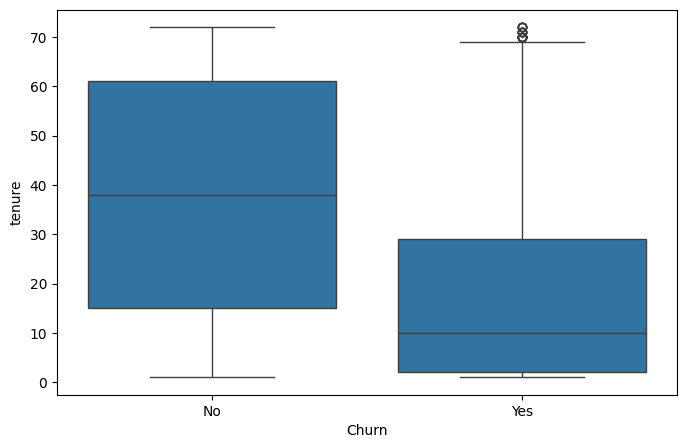

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(
  data =df_clean,
  y='tenure',
  x='Churn'
)

This is one of the strongest predictors.
Customers with short tenure leave much more often.

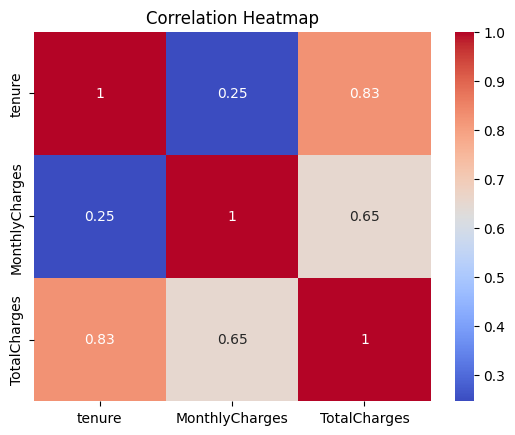

In [37]:
#selecting all the numerical columns..
numeric_df = df_clean.select_dtypes(include=['int64','float64'])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap = "coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering & Data Preprocessing for Machine Learning

In [38]:
#Encode the target variable
df_ml = df_clean.copy()
df_ml['Churn']= df_ml['Churn'].map({
    "Yes":1,
    "No":0
})

In [39]:
df_ml['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [40]:
#Separating the features and target
X= df_ml.drop("Churn",axis=1)
y=df_ml['Churn']

In [41]:
#identyfying Categorical Columns
X.select_dtypes(include="object").columns

C:\Users\acer\AppData\Local\Temp\ipykernel_17276\3716348751.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [42]:
#one hot encoding .
X= pd.get_dummies(
    X,
    drop_first=True
)

In [43]:
X.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_senior citizen,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [44]:
#training and spliting 
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#stratify=y ensures that the training and testing datasets maintain the same class distribution as the original target variable (y

In [45]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [46]:
#feature scalling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

In [48]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [49]:
model.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [50]:
y_pred = model.predict(X_test_scaled)

In [51]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [52]:
accurac= accuracy_score(y_test,y_pred)
print("Accuracy:",accurac)

Accuracy: 0.8038379530916845


In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



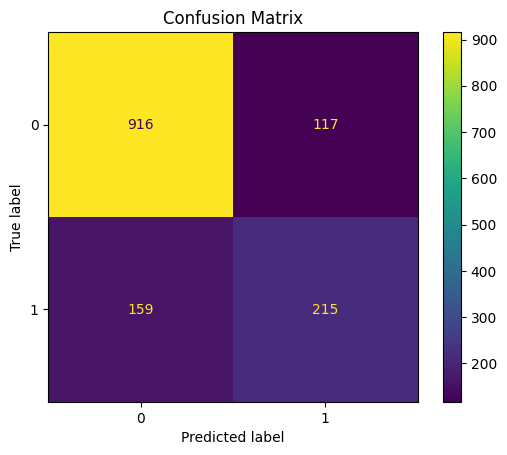

In [54]:
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()


In [55]:
auc = roc_auc_score(
    y_test,
    y_prob
)
print("ROC-AUC",auc)

ROC-AUC 0.8356727976766699


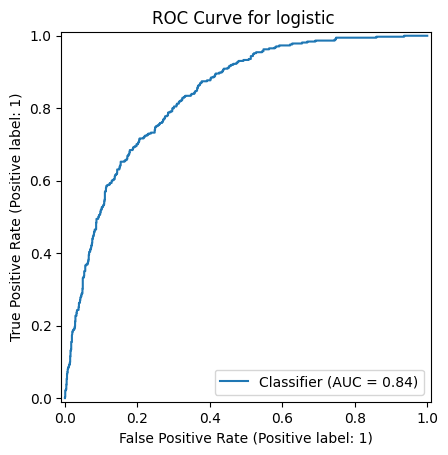

In [109]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)
plt.title("ROC Curve for logistic ")
plt.show()

In [57]:
#Features importance 
coefficients = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
}
)

In [58]:
coefficients = coefficients.sort_values(
    by  = "Coefficient",
    ascending=False
)

In [59]:
coefficients.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.727745
2,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
4,SeniorCitizen_senior citizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


In [60]:
coefficients.tail(10)
#negative coefficeints

,Feature,Coefficient
18,TechSupport_No internet service,-0.088138
16,DeviceProtection_No internet service,-0.088138
22,StreamingMovies_No internet service,-0.088138
6,Dependents_Yes,-0.105956
19,TechSupport_Yes,-0.118240
13,OnlineSecurity_Yes,-0.136804
24,Contract_One year,-0.310898
25,Contract_Two year,-0.602591
1,MonthlyCharges,-0.851551
0,tenure,-1.347613


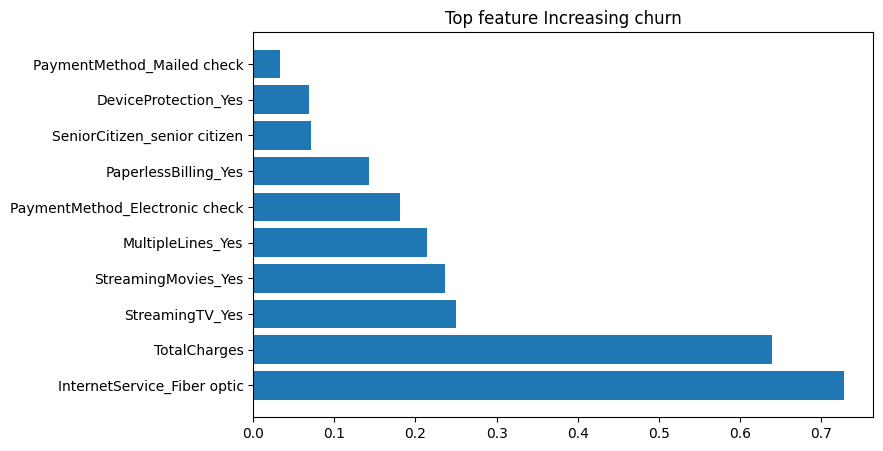

In [61]:
#visualize Feature imortance
top_positive = coefficients.head(10)
plt.figure(figsize=(8,5))
plt.barh(
    top_positive["Feature"],
    top_positive["Coefficient"]
)
plt.title("Top feature Increasing churn")
plt.show()

# upto now we only use logstic regression ,now we are gonna train the model using all decision tree,random forest ..

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [63]:
#creating models
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
tree_model = DecisionTreeClassifier(
    random_state=42
)
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

In [ ]:
#training all models
log_model.fit(X_train_scaled,y_train)  #logistic model
tree_model.fit(X_train,y_train)  #Decision tree
rf_model.fit(X_train,y_train)  # random forest


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [65]:
#making predictions 
#Logistic predictions
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:,1]  

In [76]:
#Decision tre predictions 
tree_pred = tree_model.predict(X_test)
tree_prob= tree_model.predict_proba(X_test) [:,1]

In [67]:
#Random Forest predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [70]:
#making common functins so that evalution becomes fast 
def evaluate_model(name,y_true,y_pred,y_prob):
    print("="*50)
    print(name)
    print("="*50)
    print("Accuracy :",accuracy_score(y_true,y_pred));
    print("Precision: ",precision_score(y_true,y_pred))
    print("Recall:",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))
    print("ROC AUC :",roc_auc_score(y_true,y_prob))
    print()

In [72]:
# Evaluating model
#logistic regression
evaluate_model("LogisticRegression",y_test,log_pred,log_prob)


LogisticRegression
Accuracy : 0.8038379530916845
Precision:  0.6475903614457831
Recall: 0.5748663101604278
F1 Score : 0.6090651558073654
ROC AUC : 0.8356727976766699



In [77]:
#evluating decesion tree model :
evaluate_model(
    "Decision Tree", y_test,tree_pred,tree_prob
)

Decision Tree
Accuracy : 0.7085998578535891
Precision:  0.45161290322580644
Recall: 0.44919786096256686
F1 Score : 0.450402144772118
ROC AUC : 0.6255907977905586



In [78]:
#evaluating random forest 
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

Random Forest
Accuracy : 0.7853589196872779
Precision:  0.6216216216216216
Recall: 0.4919786096256685
F1 Score : 0.5492537313432836
ROC AUC : 0.8168449197860962



In [79]:
#Building comparison table: 
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,log_pred),
        accuracy_score(y_test,tree_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,log_pred),
        precision_score(y_test,tree_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,log_pred),
        recall_score(y_test,tree_pred),
        recall_score(y_test,rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test,log_pred),
        f1_score(y_test,tree_pred),
        f1_score(y_test,rf_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,log_prob),
        roc_auc_score(y_test,tree_prob),
        roc_auc_score(y_test,rf_prob)
    ]
})

In [80]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
1,Decision Tree,0.708600,0.451613,0.449198,0.450402,0.625591
2,Random Forest,0.785359,0.621622,0.491979,0.549254,0.816845


In [100]:
import joblib
joblib.dump(rf_model, "../models/churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [104]:
def predict_customer(customer_df):
    # Convert Yes/No values to match training data
    customer_df = customer_df.copy()

    customer_df["SeniorCitizen"] = customer_df["SeniorCitizen"].map({
        "No": 0,
        "Yes": 1
    })

    # One-Hot Encode
    customer_df = pd.get_dummies(customer_df)

    # Match training columns
    customer_df = customer_df.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Scale
    customer_scaled = scaler.transform(customer_df)

    # Predict
    prediction = model.predict(customer_scaled)[0]
    probability = model.predict_proba(customer_scaled)[0][1]

    # Print Result
    print("=" * 50)

    if prediction == 1:
        print(" Prediction : Customer is likely to CHURN")
    else:
        print("Prediction : Customer is likely to STAY")

    print(f"Churn Probability : {probability:.2%}")

    print("=" * 50)

In [105]:
customer_1 = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": ["No"],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [2],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [95.50],
    "TotalCharges": [191.00]
})

In [106]:
predict_customer(customer_1)

 Prediction : Customer is likely to CHURN
Churn Probability : 75.00%


In [107]:
customer_2 = pd.DataFrame({
    "gender": ["Male"],
    "SeniorCitizen": ["No"],
    "Partner": ["Yes"],
    "Dependents": ["Yes"],
    "tenure": [70],
    "PhoneService": ["Yes"],
    "MultipleLines": ["Yes"],
    "InternetService": ["DSL"],
    "OnlineSecurity": ["Yes"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["Yes"],
    "TechSupport": ["Yes"],
    "StreamingTV": ["No"],
    "StreamingMovies": ["No"],
    "Contract": ["Two year"],
    "PaperlessBilling": ["No"],
    "PaymentMethod": ["Bank transfer (automatic)"],
    "MonthlyCharges": [55.40],
    "TotalCharges": [3878.00]
})

In [108]:
predict_customer(customer_2)

Prediction : Customer is likely to STAY
Churn Probability : 0.48%
